# Build a Just-in-Time cache for your workload

Generic caches are built for everyone's workload, so they fit no one's perfectly. In this tutorial you describe what you want in one sentence, answer three questions, and get back a cache designed for exactly your workload.

Every output below is saved from a real session, so you can read the whole tutorial without running anything.

## Setup

Install [Claude Code](https://docs.anthropic.com/en/docs/claude-code) (`npm install -g @anthropic-ai/claude-code`, then run `claude` once to log in) and open this notebook from the repo root:

```bash
uv run --with jupyter jupyter lab skydiscover/synthesize/examples/tutorial/tutorial.ipynb
```

Then run this cell once to wire the SkySynth agent team into this folder:

In [1]:
!skydiscover init --agent claude --path .

Linked the /skysynth skill and its agent roles into .claude/.
Configured ./.claude/settings.local.json (the hook that runs the tests before anything is delivered, plus the PreToolUse guards); restart Claude Code to load it.
Installed /skysynth for claude in .. Open your coding agent there and run: /skysynth <what to build>


## Your workload

An app keeps hitting the same ~100 keys. Every so often a batch job scans through 140 keys it will never ask for again. The cache holds 128 entries, so each scan can wipe out everything the app cares about:

![your workload](workload.svg)

[`workload.py`](workload.py) holds this trace and a `replay()` scorer. In real life the trace is data you export from your own system, one `key,kind` row per access.

The helper below is the only plumbing in this notebook: it sends one message to a Claude Code session and shows what comes back. It's the same session you'd have in a terminal.

In [2]:
import json
import subprocess

from IPython.display import Markdown, display

SESSION = None


def talk(message, progress=True, render=True):
    """Send one message to the Claude Code session; stream progress, render the reply."""
    global SESSION
    cmd = ["claude", "-p", message, "--model", "claude-sonnet-5",  # recommended for the tutorial
           "--output-format", "stream-json", "--verbose",
           "--dangerously-skip-permissions"]  # the agents run builds and benchmarks; sandbox accordingly
    if SESSION:
        cmd += ["--resume", SESSION]
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, text=True)
    reply = ""
    for line in proc.stdout:
        event = json.loads(line)
        SESSION = event.get("session_id", SESSION)
        if event["type"] == "assistant":
            for block in event["message"]["content"]:
                if block["type"] == "tool_use" and progress:
                    what = block["input"].get("description") or block["input"].get("summary")
                    if what:  # skip tool calls that carry no human-readable step
                        print(f"  [{block['name']}] {what}"[:110])
        elif event["type"] == "result":
            reply = event.get("result", "")
            proc.terminate()  # background helpers may linger; the turn itself is done
            break
    if render:
        display(Markdown(reply))
    return reply

## One sentence

That's the whole brief. This turn takes a few minutes: the team measures your workload first, then comes back with a few questions only you can answer, things like what "fast" means to you, what the cache may remember, and how long to search. The exact questions vary from run to run; here is what ours asked.

In [3]:
talk("/skysynth Build me a fast cache for the workload in workload.py. "
     "Ask me what you need to know before starting.")


*[... measurement output omitted ...]*

## Still need from you

- **Q1** — does "fast" include per-op cost, or is it hit rate only? (a / b / c above)
- **Q2** — evicted-key memory: **(a)** none, **(b)** bounded at a declared multiple of capacity, **(c)** unbounded. This is the consequential one.
- **Q4** — budget: **Quick (≈20)** · **Standard (≈60)** · **Thorough (≈200)** iterations.

Q3 I'll treat as **3a** on the evidence above. Reply e.g. "1b, 2b, Standard" — or "your defaults + Standard" for **1b / 2b / 3a**. The spec builder is still mining the real systems (Caffeine/W-TinyLFU, S3-FIFO, ARC, SIEVE) in the background, so nothing is idle while you decide.

Answer in one line (ours below), then run the cell.

In [4]:
your_response = "1b, 2b, Quick. Go ahead."  # <-- type your response here

reply = talk(your_response, progress=False, render=False)
print("done, answers recorded in the run folder")

done, answers recorded in the run folder


## The spec

SkySynth wrote your answers into a spec on disk, and everything built from here is held to it. The part worth reading now is the exact interface your cache will expose; the full file (`spec.json` in the run folder) pins much more, open it if you're curious.

In [5]:
import json
from pathlib import Path

spec_file = sorted(Path(".skydiscover").glob("*/specification/spec.json"))[0]
spec = json.loads(spec_file.read_text())

print(spec["title"], "\n")
iface = spec.get("interface") or {}
ops = iface.get("operations") if isinstance(iface, dict) and isinstance(iface.get("operations"), list) else list(iface)
for op in ops:  # a list of signatures, or a {name: signature} mapping
    print(" ", str(op).split("  (")[0])
print("\nfull spec:", spec_file)

Scan-resistant fixed-capacity in-memory keyed cache 

  create_cache(capacity) -> cache
  cache.get(key) -> value | None
  cache.put(key, value) -> None
  cache.size() -> int

full spec: .skydiscover/scan-resistant-cache/spec.json


## Let it run

The team designs, builds, benchmarks, audits, and repeats. After each report-back this cell scores the team's current best cache with your own `replay()`, so you can watch the number climb. When it plateaus the team isn't idle: it is attacking its own best candidate, finding defects, and fixing them without giving back the score. A Quick run takes hours; leave it running and check in.

In [6]:
import importlib.util
import time
from pathlib import Path

from workload import replay


from play import delivered, best_so_far

started_at = time.time()
turn = 0
while not delivered(since=started_at):
    turn += 1
    talk("continue", progress=False, render=False)
    score = best_so_far()
    print(f"[{turn:2d}] " + (f"best cache so far: {score:.4f}"
                             if score is not None else "designing and testing, no scored cache yet"))

best = delivered(since=started_at)[-1]
print("\ndelivered to:", best)

[ 1] designing and testing, no scored cache yet
[ 2] designing and testing, no scored cache yet
[ 3] best cache so far: 0.9224
[ 4] best cache so far: 0.9224
[ 5] best cache so far: 0.9338
[ 6] best cache so far: 0.9355
[ 7] best cache so far: 0.9409
[ 8] best cache so far: 0.9409
[ 9] best cache so far: 0.9409
[10] best cache so far: 0.9409
[11] best cache so far: 0.9409
[12] best cache so far: 0.9409
[13] best cache so far: 0.9409
[14] best cache so far: 0.9409
[15] best cache so far: 0.9409
[16] best cache so far: 0.9409



delivered to: outputs/synthesize/scan-resistant-cache_20260828_081116/best


## The result

Load the cache the team delivered and score it on your workload, next to the policies you would have used instead.

In [7]:
import importlib.util

from workload import replay

from play import load_winner
create_cache = load_winner(best)

yours = replay(create_cache)["app_hit_rate"]
fresh = replay(create_cache, seed=123)["app_hit_rate"]
print(f"your cache: {yours:.4f} on your trace, {fresh:.4f} on a trace it has never seen")

your cache: 0.9409 on your trace, 0.9438 on a trace it has never seen


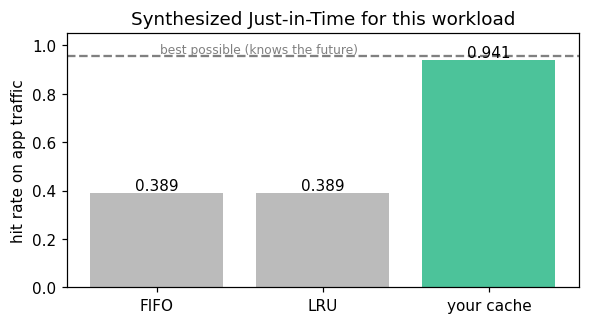

In [8]:
import matplotlib.pyplot as plt

# FIFO/LRU measured by the run itself; LFU came close but was ruled out
# for costing ~6x your per-operation budget (the run's decision log has the details)
scores = {"FIFO": 0.3886, "LRU": 0.3886, "your cache": yours}
ceiling = 0.9550  # the best any cache could do if it knew the future

plt.figure(figsize=(6, 3))
bars = plt.bar(scores.keys(), scores.values(), color=["#bbb", "#bbb", "#4cc39a"])
plt.axhline(ceiling, ls="--", c="gray")
plt.text(0.02, ceiling + 0.015, "best possible (knows the future)", fontsize=8, c="gray")
plt.bar_label(bars, fmt="%.3f")
plt.ylabel("hit rate on app traffic")
plt.ylim(0, 1.05)
plt.title("Synthesized Just-in-Time for this workload")
plt.show()

## What just happened

One sentence in, three answers, and out came a cache 2.4x better than FIFO or LRU on your traffic, within 1.5% of the theoretical ceiling. Next to the cache on disk: `spec.md` (what was asked, what was decided, and the test that checks each answer), the tests, and its score against FIFO and LRU (`score.json`).

To go further, change the trace in `workload.py` and run it again: a different workload gets a different cache. That is the Just-in-Time idea.